In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import pandas as pd


In [2]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo
if Path("helper_functions.py").is_file():
  print("helper_functions.py is already exists, skipping downloading")
else:
  print("Download helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)


helper_functions.py is already exists, skipping downloading


In [3]:
from helper_functions import accuracy_fn, plot_predictions,plot_decision_boundary

# 1. Create a multiclass toy dataset

In [4]:
# Parameters
n_samples = 1000
n_features = 2
n_classes = 4

X,y = make_blobs(n_samples,n_features,centers=n_classes,cluster_std=1.5,random_state=42)



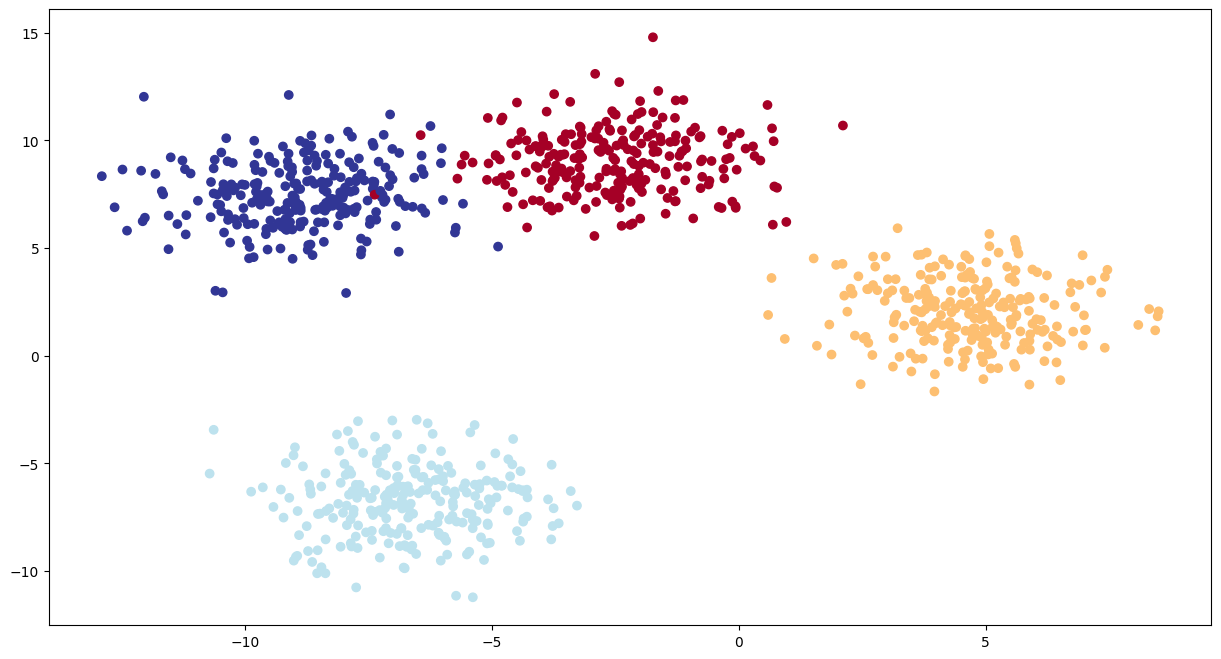

In [5]:
plt.figure(figsize=[15,8])
plt.scatter(X[:,0],X[:,1],c=y,cmap=plt.cm.RdYlBu)


# 2. Split Dataset and Convert to Tensor

In [6]:
# Split data
X_train,X_test,y_train,y_test = train_test_split(X,y,
                                                 test_size=0.2,
                                                 random_state=42)

# Convert to tensor
X_train, y_train = torch.from_numpy(X_train).type(torch.float), torch.from_numpy(y_train).type(torch.float)
X_test, y_test = torch.from_numpy(X_test).type(torch.float), torch.from_numpy(y_test).type(torch.float)

## Device diagnostic

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


# 3.Build a Multiclass Classification Model

In [8]:
class MulticlassClassification(nn.Module):
  def __init__(self,input_features,output_features,hidden_units=8):
    """
    Arg:
    input_features (int): Number of input features
    output_features (int): Number of output_features/ classes
    hidden_units (int): Number of hidden units/extracted features btw layers, default is 8
    """
    super().__init__()
    self.input_features = input_features
    self.output_features = output_features
    self.hidden_units = hidden_units
    # Create the layer
    self.Linear_layers_stack = nn.Sequential(
        nn.Linear(in_features=self.input_features,out_features=self.hidden_units),
        nn.Linear(in_features=self.hidden_units,out_features=self.hidden_units),
        nn.Linear(in_features=self.hidden_units,out_features=self.output_features)
    )

  def forward(self,x):
    return self.Linear_layers_stack(x)

In [9]:
model_blob = MulticlassClassification(input_features=2,
                                      output_features=n_classes,
                                      hidden_units=8).to(device)
model_blob

MulticlassClassification(
  (Linear_layers_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

## 3.1 Define Loss function and Optimizer

In [10]:
# Loss function
loss_fn = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(params=model_blob.parameters(),
                             lr=0.01)


# 4. Train the model

In [11]:
# Set randomness
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Put train & test data on device
X_train,y_train = X_train.to(device), y_train.to(device)
X_test,y_test = X_test.to(device), y_test.to(device)

# Initialize
epochs = 1000

for epoch in range(epochs):
  # Turn on training mode
  model_blob.train()

  # Forward
  y_train_logits = model_blob(X_train)
  y_train_pred = torch.argmax(torch.softmax(y_train_logits,dim=1),dim=1)

  # Calculate loss
  train_loss = loss_fn(y_train_logits,y_train.type(torch.LongTensor))

  # Calculate accuracy
  acc_train = accuracy_fn(y_true=y_train,y_pred=y_train_pred)

  # Zero grad
  model_blob.zero_grad()

  # Backprob
  train_loss.backward()

  # Grad. descent
  optimizer.step()

  # Testing
  model_blob.eval()
  with torch.inference_mode():
    # Forward
    y_test_logits = model_blob(X_test)
    y_test_pred = torch.argmax(torch.softmax(y_test_logits,dim=1),dim=1)
    # Calculate the loss
    test_loss = loss_fn(y_test_logits,y_test.type(torch.LongTensor))
    # Calculate the accuracy
    acc_test = accuracy_fn(y_true=y_test,y_pred=y_test_pred)

    if epoch % 100 == 0:
      print(f"Epoc: {epoch} | Training Loss: {train_loss:.3f} | Training Accuracy: {acc_train:.2f} | Test Loss: {test_loss:.3f} | Test Accuracy: {acc_test:.2f}")


Epoc: 0 | Training Loss: 1.347 | Training Accuracy: 29.38 | Test Loss: 1.084 | Test Accuracy: 49.00
Epoc: 100 | Training Loss: 0.024 | Training Accuracy: 99.50 | Test Loss: 0.014 | Test Accuracy: 99.50
Epoc: 200 | Training Loss: 0.020 | Training Accuracy: 99.50 | Test Loss: 0.009 | Test Accuracy: 100.00
Epoc: 300 | Training Loss: 0.018 | Training Accuracy: 99.50 | Test Loss: 0.007 | Test Accuracy: 100.00
Epoc: 400 | Training Loss: 0.018 | Training Accuracy: 99.38 | Test Loss: 0.005 | Test Accuracy: 100.00
Epoc: 500 | Training Loss: 0.017 | Training Accuracy: 99.50 | Test Loss: 0.005 | Test Accuracy: 100.00
Epoc: 600 | Training Loss: 0.017 | Training Accuracy: 99.50 | Test Loss: 0.004 | Test Accuracy: 100.00
Epoc: 700 | Training Loss: 0.017 | Training Accuracy: 99.50 | Test Loss: 0.004 | Test Accuracy: 100.00
Epoc: 800 | Training Loss: 0.017 | Training Accuracy: 99.50 | Test Loss: 0.004 | Test Accuracy: 100.00
Epoc: 900 | Training Loss: 0.017 | Training Accuracy: 99.50 | Test Loss: 0.00

# 5. Evaluate the Model

Text(0.5, 1.0, 'Test')

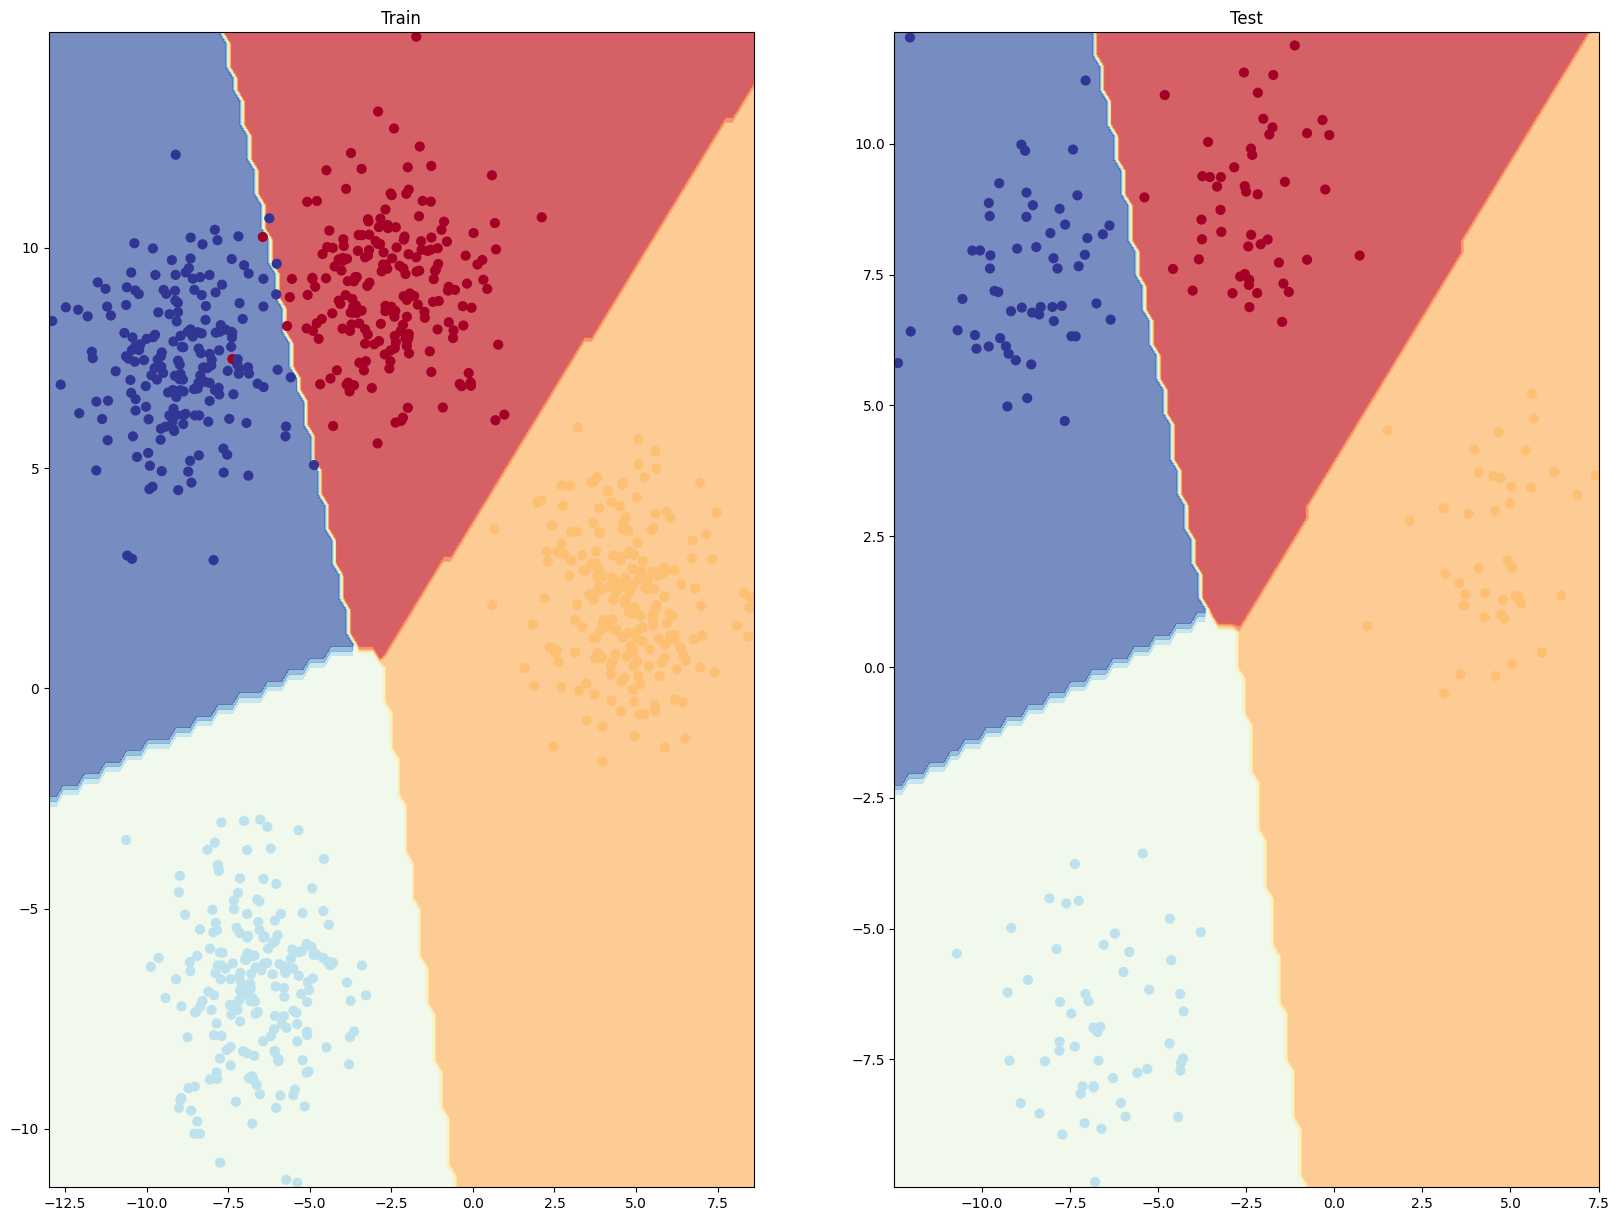

In [16]:
plt.figure(figsize=[20,15])
plt.subplot(121)
plot_decision_boundary(model_blob,X_train,y_train)
plt.title("Train")
plt.subplot(122)
plot_decision_boundary(model_blob,X_test,y_test)
plt.title("Test")